# Visión por Computadora I — TP1

**Integrantes:**

Carmen Rodriguez

Matias Bovio

Gonzalo Rodriguez


In [1]:
%matplotlib inline
#%matplotlib qt

# OpenCV-Python utiliza NumPy para el manejo de imágenes
import numpy as np
# cv2 es el módulo python para acceder a OpenCV
import cv2 as cv
# Usamos matplotlib para mostrar imágenes e histogramas
import matplotlib.pyplot as plt
import os

print(f'OpenCV: {cv.__version__}')


OpenCV: 5.0.0


In [2]:
def show_images(imgs, titles, cols=None, size=4, cmap=None):
    '''
    Parameters
    ----------
    imgs: list of np.ndarray
        Imágenes a mostrar (RGB o escala de grises)
    titles: list of str
        Título de cada imagen
    cols: int
        Cantidad de columnas de la grilla
    cmap: str
        Mapa de color de matplotlib (usar 'gray' para imágenes monocromáticas)
    '''
    n = len(imgs)
    cols = cols or n
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(size * cols, size * 0.9 * rows))
    for i, (im, t) in enumerate(zip(imgs, titles)):
        ax = plt.subplot(rows, cols, i + 1)
        # vmin/vmax fijos para que matplotlib no reescale el rango de grises
        ax.imshow(im, cmap=cmap, vmin=0 if cmap else None, vmax=255 if cmap else None)
        ax.set_title(t, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


## Parte 1 — White Patch

### 1.1 El algoritmo

El color que registra la cámara depende tanto de la reflectancia de los objetos como del color de la
fuente de iluminación. *White Patch* busca compensar ese segundo factor con una hipótesis muy simple:
**el valor máximo de cada canal corresponde a una superficie blanca iluminada por la luz de la escena**.
Por lo tanto, si se escala cada canal (`cv.split` / `cv.merge`) para que ese máximo pase a valer 255, el "blanco de la escena"
se mapea al blanco puro $(255, 255, 255)$ y el resto de los colores se corrige en la misma proporción:

$$
(R, G, B) \;\rightarrow\; \left( \frac{255}{R_{max}} R,\; \frac{255}{G_{max}} G,\; \frac{255}{B_{max}} B \right)
$$

Es una **transformación diagonal** (cada canal se multiplica por su propio factor de ganancia, sin mezclar
canales), el mismo tipo de operación que hace un balance de blancos clásico.

La implementación de abajo recibe un parámetro `percentile` (por defecto 100 = máximo estricto) porque,
como se verá en la sección de fallas, el máximo estricto es muy sensible a píxeles saturados o a *outliers*.


In [3]:
def white_patch(input_image:np.ndarray, percentile:float=100) -> np.ndarray:
    '''
    Parameters
    ----------
    input_image:np.ndarray
        Imagen color RGB de 8 bits
    percentile:
        Percentil (0, 100] usado como valor de "blanco" en cada canal.
        Con 100 se usa el máximo estricto de cada canal (algoritmo original).
        Un valor menor (ej. 99) hace al método robusto a píxeles saturados y outliers.

    Return
    ------
    Imagen corregida como np.ndarray (uint8, RGB)
    '''
    # Desensamblo los canales para trabajarlos por separado
    canales = cv.split(input_image)
    canales_new = []
    for c in canales:
        # Valor de referencia ("blanco") del canal
        ref = np.percentile(c, percentile)
        ref = max(ref, 1)                       # evita división por cero en canales apagados
        # Normalizo al blanco puro: c -> (255 / ref) * c
        c_new = (255 / ref) * c.astype('float64')
        # Clip trunca a lo que se le diga (0 a 255)
        np.clip(c_new, 0, 255, out=c_new)
        # Hay que castear a 8 bits
        canales_new.append(c_new.astype('uint8'))
    # Vuelvo a ensamblar la imagen
    return cv.merge(canales_new)


def channel_stats(img:np.ndarray, percentile:float=99):
    '''
    Devuelve (máximo, percentil, media) de cada canal, para inspeccionar la hipótesis del algoritmo
    '''
    canales = cv.split(img)
    mx   = np.array([c.max() for c in canales])
    pct  = np.array([np.percentile(c, percentile) for c in canales])
    mean = np.array([c.mean() for c in canales])
    return mx, pct, mean


### 1.2 Imágenes de entrada

imagen          shape               max RGB           p99 RGB                 media RGB
test_blue.png   (100, 278, 3)       [165 138 200]     [153. 122. 180.]        [103.   69.5 100.7]
test_green.png  (100, 278, 3)       [210 250 171]     [193. 230. 150.]        [129.4 131.1  83.6]
test_red.png    (99, 276, 3)        [247 157 175]     [230. 143. 163.]        [155.8  81.1  91.2]
wp_blue.jpg     (1600, 1200, 3)     [255 255 255]     [117.  86. 254.]        [ 17.6  17.1 121.5]
wp_green.png    (571, 363, 3)       [126 252 155]     [ 88. 244. 120.]        [ 26.2 102.8  34.7]
wp_green2.jpg   (1600, 1200, 3)     [170 255 172]     [ 70. 255.  56.]        [  4.4 126.1   4. ]
wp_red.png      (813, 481, 3)       [255 134 122]     [255.  74. 102.]        [122.9  18.8  25.2]
wp_red2.jpg     (1600, 1200, 3)     [255 201 203]     [255. 119. 119.]        [128.5  21.   29.7]


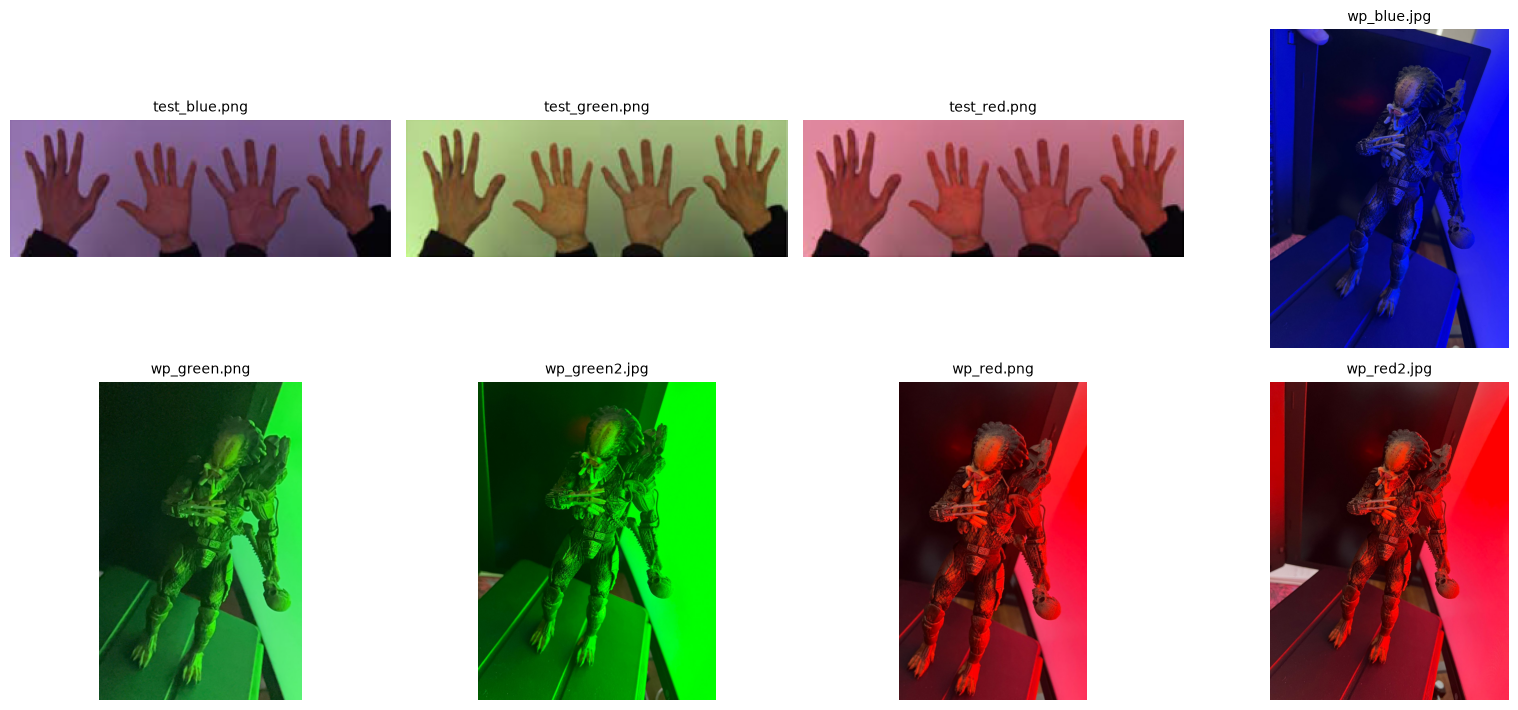

In [4]:
wp_dir = 'white_patch'
files = sorted(os.listdir(wp_dir))

originals = {}
for f in files:
    # Cargo la imagen color (IMREAD_COLOR fuerza 3 canales BGR y descarta el canal alpha de los png)
    img_color = cv.imread(os.path.join(wp_dir, f), cv.IMREAD_COLOR)
    # Paso de BGR a RGB invirtiendo el orden de los canales con Numpy
    originals[f] = img_color[..., ::-1]

print(f"{'imagen':<16}{'shape':<20}{'max RGB':<18}{'p99 RGB':<24}{'media RGB'}")
for name, im in originals.items():
    mx, p99, mean = channel_stats(im)
    print(f"{name:<16}{str(im.shape):<20}{str(mx):<18}{str(p99.round(0)):<24}{mean.round(1)}")

show_images(list(originals.values()), list(originals.keys()), cols=4)


Hay dos familias de imágenes:

- **`test_*`**: manos sobre fondo claro con un tinte azul, verde o rojo. Ningún canal llega a 255
  (los máximos están entre 138 y 250), es decir, hay margen para que el escalado tenga efecto.
- **`wp_*`**: un muñeco iluminado por una luz LED fuertemente coloreada. En todas menos `wp_green.png`
  el canal dominante **ya está saturado en 255** (por la propia fuente de luz),
  mientras que los otros dos canales tienen máximos altos por unos pocos píxeles pero medias muy bajas.

Esa diferencia va a ser determinante en el resultado.


### 1.3 Resultados: máximo estricto vs. percentil 99

Se aplica el algoritmo en su versión original (máximo estricto, `percentile=100`) y en una versión robusta que usa el percentil 99 como estimador del "blanco". Se muestran las tres imágenes juntas para poder compararlas en una sola grilla; el análisis de cada caso está en las secciones 1.4 y 1.5.

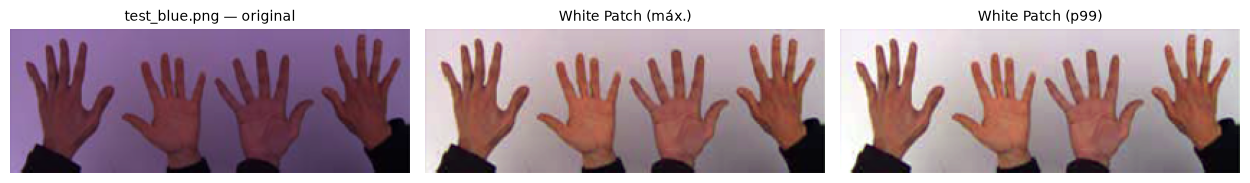

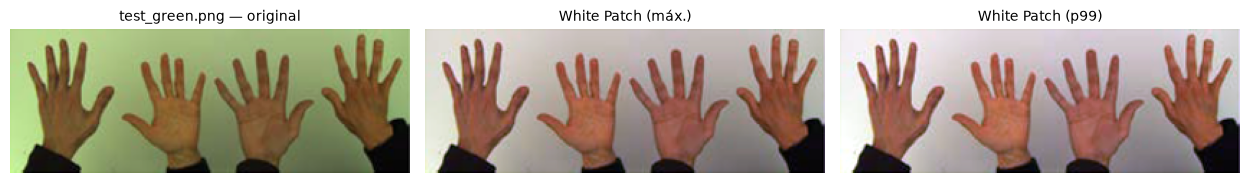

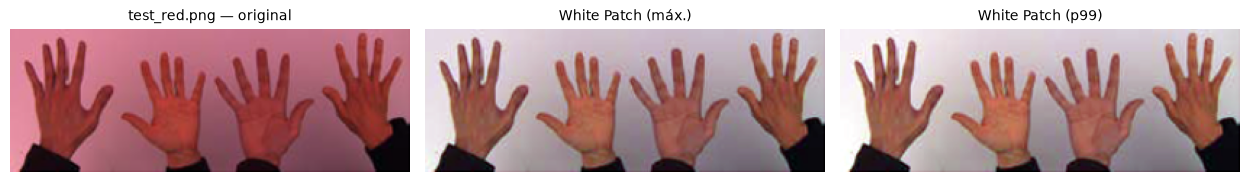

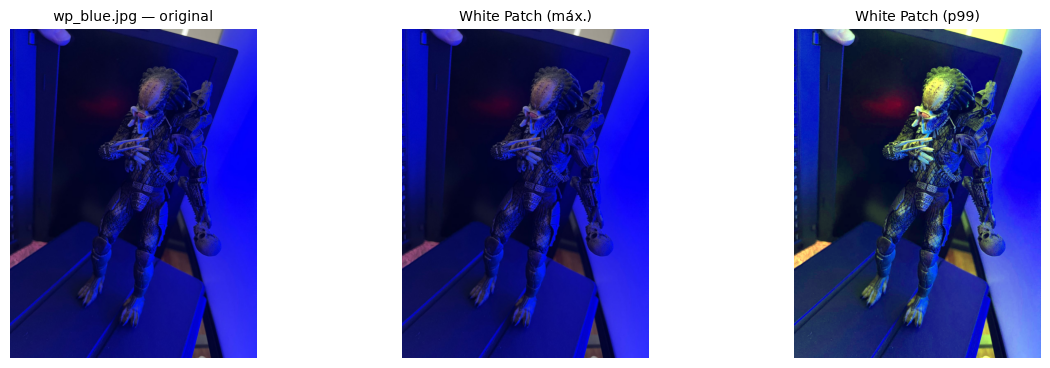

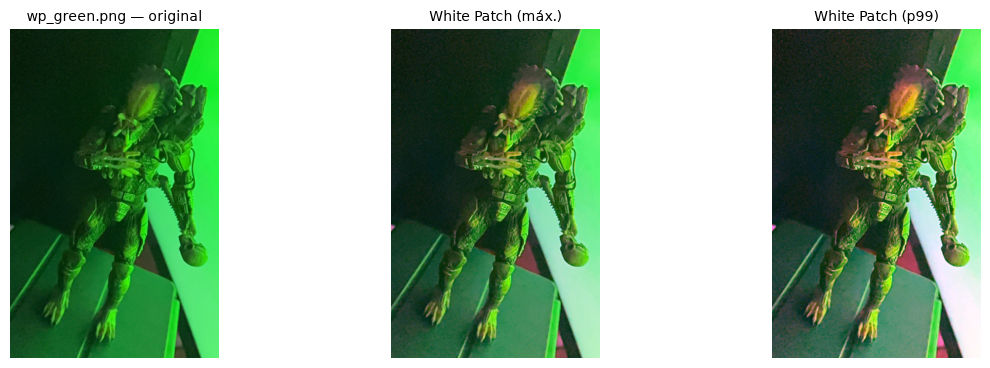

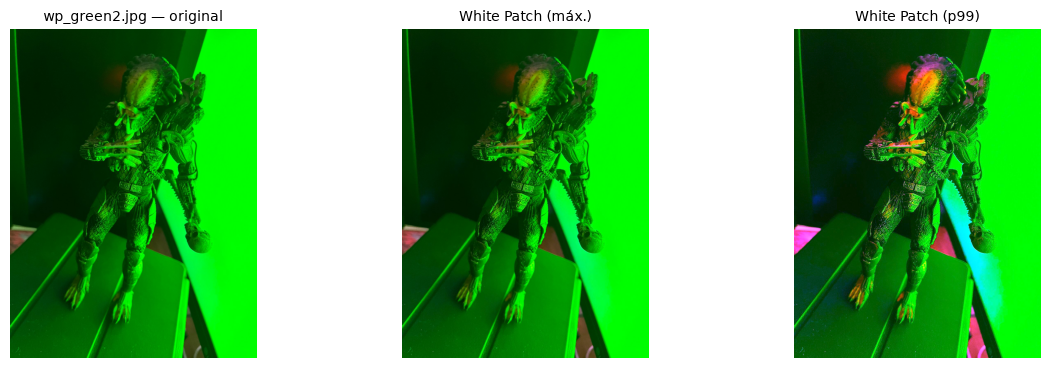

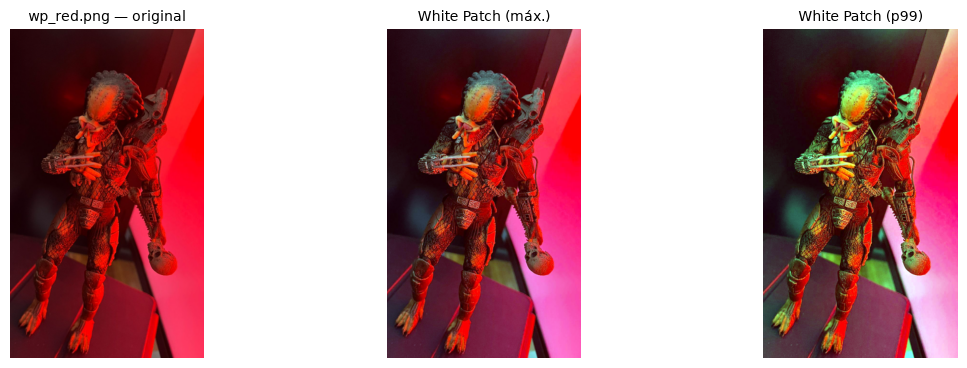

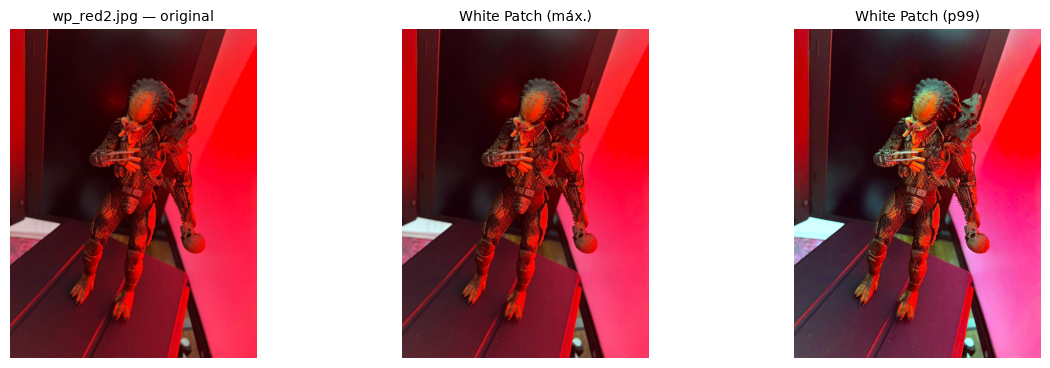

In [5]:
P = 99  # percentil elegido como estimador robusto del "blanco"

corrected_max = {name: white_patch(im, percentile=100) for name, im in originals.items()}
corrected_pct = {name: white_patch(im, percentile=P)   for name, im in originals.items()}

for name in originals:
    show_images([originals[name], corrected_max[name], corrected_pct[name]],
                [f"{name} — original", "White Patch (máx.)", f"White Patch (p{P})"],
                cols=3, size=4.2)

### 1.4 Análisis de resultados y fallas

**Donde funciona (`test_blue`, `test_green`, `test_red`).** El fondo, que es la superficie más clara de la
escena y actúa como "parche blanco", pasa a ser aproximadamente neutro y el tono de piel de las manos
se recupera de forma razonable en los tres casos. Se cumple la hipótesis del algoritmo: existe una
superficie blanca en la escena y no hay canales saturados, por lo que los tres factores de ganancia son
informativos.

**Donde falla (`wp_blue`, `wp_green2`, `wp_red`, `wp_red2`).** La corrección prácticamente **no cambia
nada**: la imagen sigue siendo azul/verde/roja. La causa se ve en la tabla de estadísticas:

1. **Saturación del canal dominante.** Si $R_{max} = 255$ el factor de ganancia es $255/255 = 1$ y ese
   canal queda intacto. El algoritmo no tiene forma de "bajar" el canal que está de más; sólo puede
   "subir" a los otros.
2. **Outliers en los canales débiles.** Los canales no dominantes tienen máximos altos (p. ej. 203/201 en
   `wp_red2`) producidos por unos pocos píxeles: reflejos especulares, la fuente de luz en cuadro, ruido
   del sensor o artefactos de compresión JPEG. Esos píxeles fijan un factor de ganancia chico
   ($255/203 \approx 1.25$) aunque el 99 % de la imagen esté en valores mucho menores (percentil 99 ≈ 119).
   El resultado es que la escena sigue dominada por el canal saturado.
3. **Violación de la hipótesis de base.** En estas escenas no hay una superficie blanca visible: el
   "blanco" que estima el algoritmo es el reflejo de la propia luz LED, que es de color puro. El máximo por
   canal no representa entonces al iluminante.

`wp_green.png` es un caso intermedio: no hay ningún canal en 255, así que hay corrección, pero como el
"blanco" estimado sigue viniendo de reflejos aislados, el resultado queda con un tinte verdoso y el
fondo se ve algo lavado.

**Otra falla estructural:** al usar el máximo global, *un solo píxel* decide la ganancia de todo un canal.
Basta un píxel de ruido para invalidar la corrección. Esto motiva reemplazar el máximo por un
**percentil**, que ignora esa cola de valores extremos.


### 1.5 Corrección: usar un percentil en lugar del máximo

Volviendo a la grilla de la sección 1.3, con el percentil 99 el "blanco" de referencia deja de estar definido por unos pocos píxeles aislados
y pasa a estar definido por el 1 % más claro de la imagen. El efecto depende de la imagen:

- En las `test_*` el resultado es casi igual al del máximo estricto (no había outliers), apenas algo más
  luminoso porque el 1 % de píxeles más claros se recorta a 255.
- En `wp_green.png` la mejora es clara: el muñeco recupera tonos amarillos/metálicos y el fondo se
  neutraliza.
- En `wp_blue`, `wp_green2`, `wp_red` y `wp_red2` la mejora con p99 es **parcial**: el muñeco gana algo de
  detalle y color, pero la escena sigue dominada por el tinte del LED. La razón es que la iluminación
  coloreada abarca una fracción grande de la imagen (fondo, mesa, reflejos), no un 1 % de outliers, y el
  percentil 99 sigue cayendo dentro de esa zona saturada.

Para ver hasta dónde puede llegar el método se hace un barrido de percentiles sobre dos imágenes
representativas: `wp_red2.jpg` (canal dominante saturado, canales débiles con algo de señal) y
`wp_green2.jpg` (canal dominante saturado, canales débiles prácticamente sin señal).


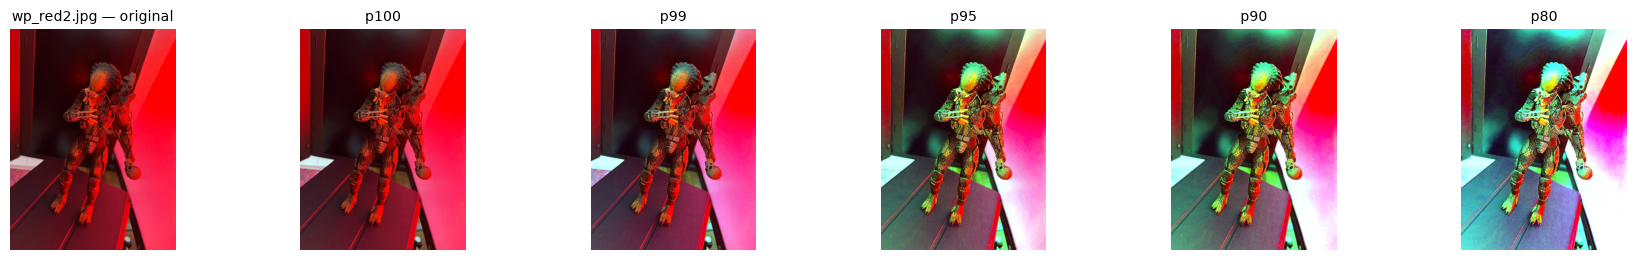

p100:   9.1% sat.  p99:  10.1% sat.  p95:  15.6% sat.  p90:  25.8% sat.  p80:  33.2% sat.


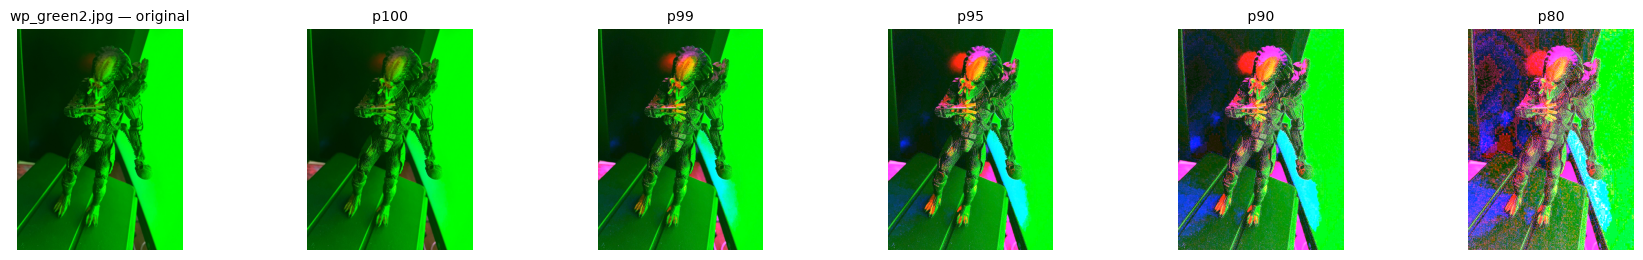

p100:   5.1% sat.  p99:   6.8% sat.  p95:  12.9% sat.  p90:  29.8% sat.  p80:  51.6% sat.


In [6]:
percentiles = [100, 99, 95, 90, 80]
for name in ["wp_red2.jpg", "wp_green2.jpg"]:
    imgs = [originals[name]] + [white_patch(originals[name], p) for p in percentiles]
    titles = [f"{name} — original"] + [f"p{p}" for p in percentiles]
    show_images(imgs, titles, cols=6, size=3.0)
    # fracción de píxeles saturados en al menos un canal, para cuantificar el clipping
    print("  ".join(f"p{p}: {(im == 255).any(axis=2).mean()*100:5.1f}% sat." for p, im in zip(percentiles, imgs[1:])))


**Lo que muestra el barrido.** Bajando el percentil a 90–95 el muñeco recupera colores plausibles en
`wp_red2` (y lo mismo ocurre en `wp_blue` y `wp_green`, que no se incluyen en el barrido para no alargar la notebook); en ese rango el percentil ya cae por debajo de la zona iluminada
directamente por el LED y el "blanco" estimado se parece más al del objeto. Pero aparecen dos límites que
ningún percentil resuelve:

1. **Información recortada en el canal dominante.** Las zonas donde el LED pega de lleno están en 255 en
   ese canal *desde la captura*: la cámara ya perdió el detalle. Al escalar los otros canales esas zonas
   siguen siendo rojo/verde/azul puro (el fondo de ambas imágenes queda igual de saturado con
   cualquier percentil).
2. **Amplificación de ruido en los canales débiles.** En `wp_green2` los canales R y B tienen una media de
   ~4/255: prácticamente no hay señal, sólo ruido del sensor y artefactos JPEG. Con p80 la ganancia de esos
   canales es tan grande que la imagen se llena de ruido magenta. Cuanto más pura es la luz, menos
   información de color queda en los otros canales y menos se puede recuperar.

A esto se suma el costo general del percentil: todo píxel por encima del umbral se satura (*clipping*),
como muestra el porcentaje impreso debajo de cada barrido, que crece a medida que baja el percentil.
El percentil es entonces un **hiperparámetro** que hay que elegir según la escena: 99 es un buen valor
por defecto para eliminar outliers puntuales sin dañar las altas luces; valores de 90–95 son necesarios
cuando el iluminante domina una parte grande de la imagen, aceptando más clipping y más ruido.


### 1.6 Conclusiones de la Parte 1

- White Patch es una corrección diagonal muy simple y barata que funciona bien cuando **(a)** existe una
  superficie blanca/clara en la escena y **(b)** ningún canal está saturado.
- Falla completamente cuando el canal del iluminante está en 255 (no puede reducir un canal) y cuando el
  máximo de los otros canales está definido por outliers (reflejos, ruido, compresión).
- Estimar el "blanco" con un **percentil** en lugar del máximo estricto resuelve el problema de los
  outliers puntuales (p99) y, con valores más bajos (p90–95), permite recuperar el color del objeto aun
  bajo iluminación muy coloreada, a costa de más clipping en las altas luces y de amplificar el ruido de
  los canales débiles. El percentil es un hiperparámetro que depende de la escena.
- Hay pérdidas que ninguna versión del método revierte: las zonas saturadas en captura y los canales que
  llegan sin señal. Es una limitación de los datos, no del algoritmo.
- Aun así, el método sigue dependiendo de la hipótesis de que "lo más claro es blanco". Si el objeto más
  claro de la escena tiene color propio (p. ej. una pared amarilla), la corrección introduce un tinte
  incorrecto. Alternativas como *Gray World* (asumir que el promedio de la escena es gris) parten de otra
  hipótesis y pueden combinarse con ésta.


## Parte 2 — Histogramas

### 2.1 Lectura en escala de grises y visualización


Tamaño img1: (288, 287) pix  dtype: uint8  min: 2  max: 255  media: 154.81  desvío: 75.34
Tamaño img2: (288, 287) pix  dtype: uint8  min: 2  max: 255  media: 154.81  desvío: 75.34


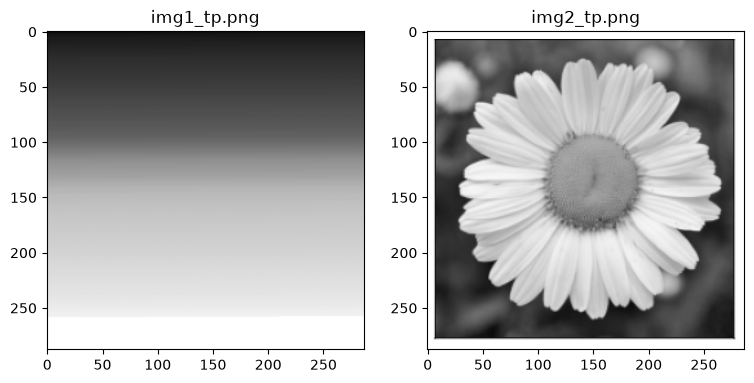

In [7]:
# Cargar las imágenes en modo monocromático (un canal)
img1 = cv.imread('img1_tp.png', cv.IMREAD_GRAYSCALE)
img2 = cv.imread('img2_tp.png', cv.IMREAD_GRAYSCALE)

# Dimensión y estadísticas de las imágenes
for nombre, im in (('img1', img1), ('img2', img2)):
    print(f'Tamaño {nombre}: {im.shape} pix  dtype: {im.dtype}  min: {im.min()}  max: {im.max()}  '
          f'media: {im.mean():.2f}  desvío: {im.std():.2f}')

# Muestra las imágenes en tonos de grises (vmin/vmax para que no se reescale el rango)
plt.figure(figsize=(9, 4.5))
ax1 = plt.subplot(121)
ax1.imshow(img1, cmap='gray', vmin=0, vmax=255)
ax1.set_title('img1_tp.png')
ax2 = plt.subplot(122)
ax2.imshow(img2, cmap='gray', vmin=0, vmax=255)
ax2.set_title('img2_tp.png')
plt.show()


`img1_tp.png` es un degradé vertical (negro arriba, blanco abajo); `img2_tp.png` es la foto de una flor.
Visualmente no tienen nada en común, pero las estadísticas globales (media, desvío, rango) son idénticas.

### 2.2 Histogramas

Se calcula el histograma con `np.histogram(img.ravel(), bins, [0, 256])`. Como las imágenes son de 8 bits, la resolución máxima es
**256 bins** (un bin por nivel de gris), que es lo que se usa como referencia. Se muestra también una
versión con **32 bins** (8 niveles por bin): reduce el ruido del conteo y es más habitual cuando el
histograma se usa como descriptor, porque un vector de 32 componentes es más compacto y menos sensible
a pequeños cambios de brillo que uno de 256.


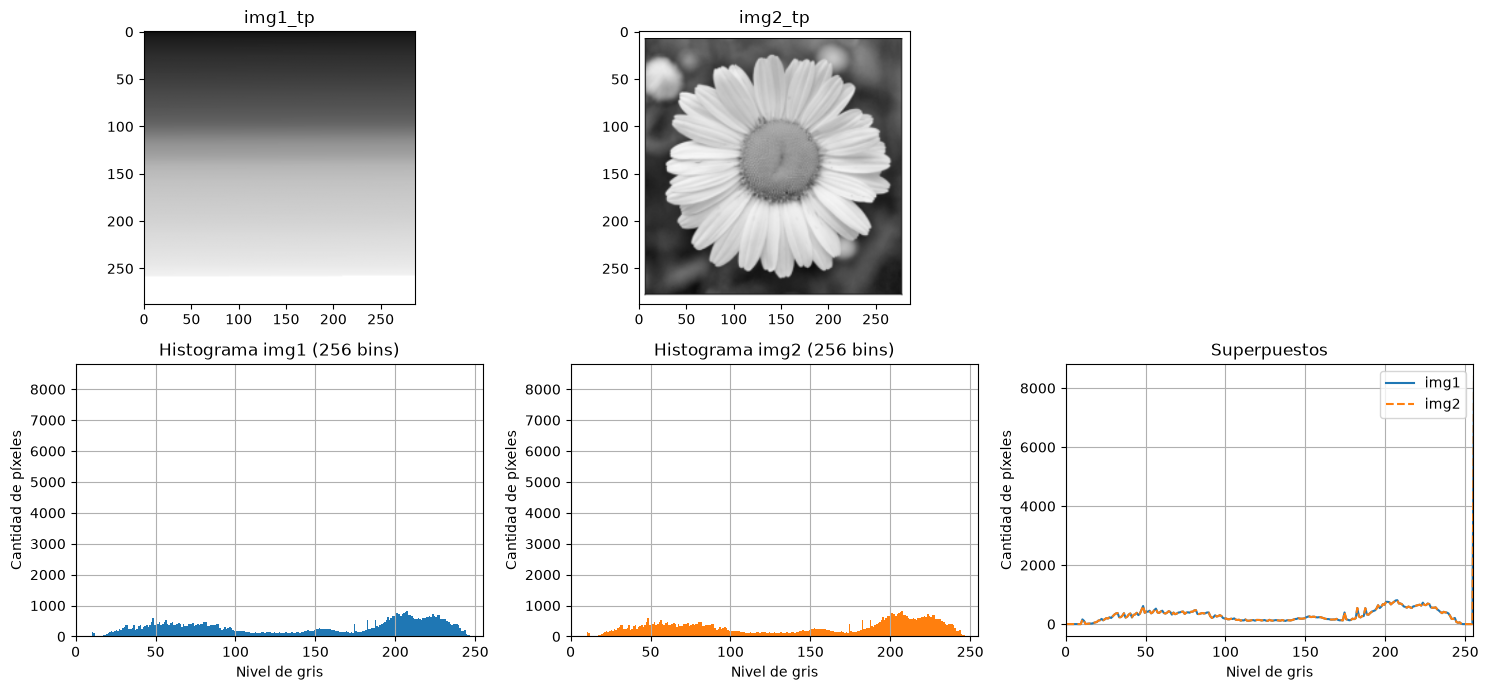

[256 bins] diferencia absoluta máxima entre histogramas: 0   correlación: 1.0000


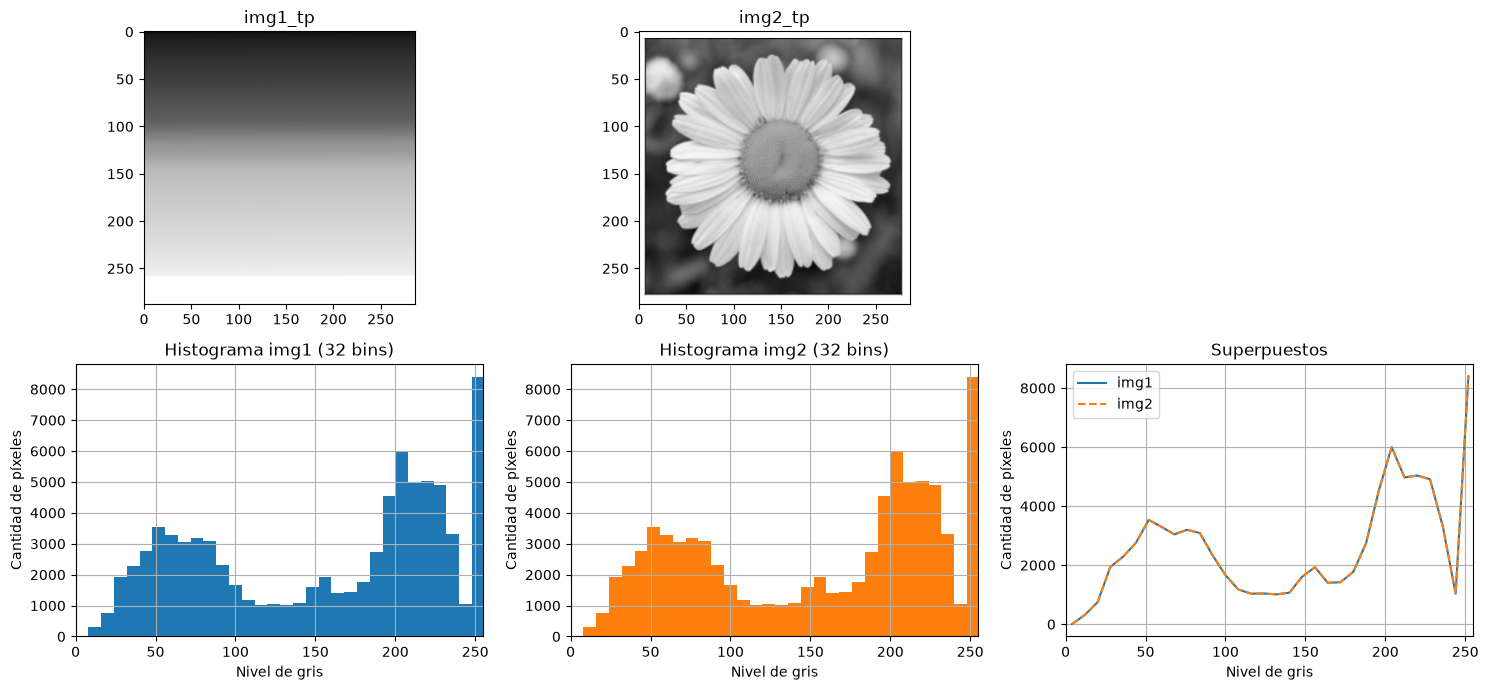

[32 bins] diferencia absoluta máxima entre histogramas: 0   correlación: 1.0000


In [8]:
for n_bins in (256, 32):
    # Calculando los histogramas
    hist1, bins1 = np.histogram(img1.ravel(), n_bins, [0, 256])
    hist2, bins2 = np.histogram(img2.ravel(), n_bins, [0, 256])
    # Centro de cada bin para el eje x (nivel de gris)
    centros = (bins1[:-1] + bins1[1:]) / 2

    # Nueva figura: imagen + histograma de cada una, y ambos histogramas superpuestos
    fig = plt.figure(figsize=(15, 7))

    ax1 = plt.subplot(231)
    ax1.imshow(img1, cmap='gray', vmin=0, vmax=255)
    ax1.set_title('img1_tp')
    ax2 = plt.subplot(232)
    ax2.imshow(img2, cmap='gray', vmin=0, vmax=255)
    ax2.set_title('img2_tp')

    ax3 = plt.subplot(234)
    ax3.bar(centros, hist1, width=256 / n_bins)
    ax3.set_title(f'Histograma img1 ({n_bins} bins)')
    ax4 = plt.subplot(235)
    ax4.bar(centros, hist2, width=256 / n_bins, color='tab:orange')
    ax4.set_title(f'Histograma img2 ({n_bins} bins)')

    ax5 = plt.subplot(236)
    ax5.plot(centros, hist1, label='img1')
    ax5.plot(centros, hist2, '--', label='img2')
    ax5.set_title('Superpuestos')
    ax5.legend()

    for ax in (ax3, ax4, ax5):
        ax.set_xlabel('Nivel de gris')
        ax.set_ylabel('Cantidad de píxeles')
        ax.set_xlim(0, 255)
        ax.grid()
    plt.tight_layout()
    plt.show()

    # Comparación numérica: diferencia bin a bin y correlación (cv.compareHist requiere float32)
    corr = cv.compareHist(hist1.astype('float32'), hist2.astype('float32'), cv.HISTCMP_CORREL)
    print(f'[{n_bins} bins] diferencia absoluta máxima entre histogramas: {np.abs(hist1 - hist2).max()}   correlación: {corr:.4f}')


¿Mismo histograma (256 bins)?   True
¿Misma imagen píxel a píxel?     False
¿Mismos valores ordenados?       True


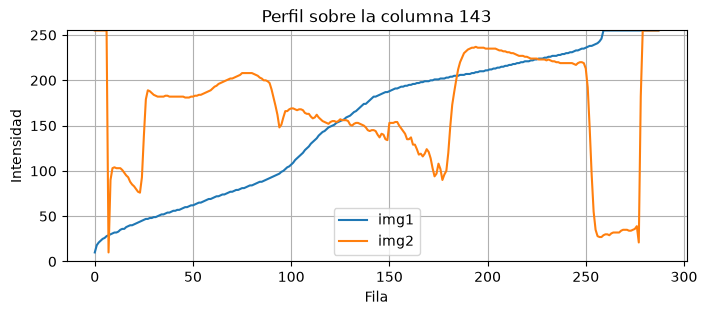

In [9]:
# Verificación exacta: mismos píxeles en distinto orden
hist1, _ = np.histogram(img1.ravel(), 256, [0, 256])
hist2, _ = np.histogram(img2.ravel(), 256, [0, 256])
print(f'¿Mismo histograma (256 bins)?   {np.array_equal(hist1, hist2)}')
print(f'¿Misma imagen píxel a píxel?     {np.array_equal(img1, img2)}')
print(f'¿Mismos valores ordenados?       {np.array_equal(np.sort(img1.ravel()), np.sort(img2.ravel()))}')

# Un perfil de intensidad (columna central) sí muestra la diferencia que el histograma no ve
idx_col = img1.shape[1] // 2
plt.figure(figsize=(8, 3))
plt.plot(img1[:, idx_col], label='img1')
plt.plot(img2[:, idx_col], label='img2')
plt.xlabel('Fila')
plt.ylabel('Intensidad')
plt.title(f'Perfil sobre la columna {idx_col}')
plt.ylim(0, 255)
plt.grid()
plt.legend()
plt.show()


### 2.3 Qué se observa

Los dos histogramas son **exactamente iguales**, bin a bin, con cualquier número de bins. Las dos
imágenes contienen el mismo multiconjunto de niveles de gris (una es, en efecto, una permutación de los
píxeles de la otra) y sin embargo una es un degradé y la otra una flor.

Esto ilustra la limitación fundamental del histograma: es una estadística **global de primer orden**.
Cuenta cuántos píxeles hay de cada intensidad pero **descarta por completo la información espacial**:
dónde está cada píxel, qué vecinos tiene, qué bordes, texturas o formas se generan. Cualquier
reordenamiento de los píxeles (rotar, reflejar, trasladar, o directamente barajarlos) deja el histograma
intacto.

### 2.4 ¿Sirven los histogramas como *features* para clasificación/detección?

**Como único descriptor, no.** Este ejemplo lo demuestra de forma extrema: un clasificador que reciba
solamente el histograma no tiene ninguna forma de distinguir `img1` de `img2`, porque su entrada es
idéntica. Un modelo de clasificación necesita capturar formas, bordes y estructura; un detector además
necesita localizar el objeto, y el histograma ni siquiera contiene la noción de posición. A eso se suma
que el histograma es sensible a cambios de iluminación y contraste (desplazan o estiran la distribución)
aunque el contenido semántico no cambie.

**Como descriptor complementario o para tareas específicas, sí puede ser útil**, porque tiene virtudes
propias:

- Es muy barato de calcular y compacto (32–256 números).
- Es invariante a traslación, rotación y escala (en la medida en que la proporción de intensidades se
  mantenga), lo que en algunos problemas es una ventaja y no un defecto.
- Captura bien propiedades globales de apariencia: brillo, contraste, rango dinámico, dominancia de color
  (si se calcula por canal o en HSV). Sirve para detectar imágenes sobre/subexpuestas, escenas de día vs.
  noche, clasificar por color dominante, hacer *retrieval* grueso por similitud de color, detectar cambios
  de escena en video, o como *feature* adicional junto a otras en un clasificador clásico.
- Aplicado **localmente** (histogramas por bloques o celdas) recupera parte de la información espacial;
  de hecho descriptores muy usados como HOG o LBP son, en esencia, histogramas locales de orientaciones
  de gradiente o de patrones binarios.

En resumen: el histograma global es un buen descriptor de *cómo se distribuyen las intensidades*, pero
no de *qué hay en la imagen*. Para clasificación/detección hay que combinarlo con descriptores que
conserven estructura espacial (bordes, texturas, puntos de interés, o directamente las representaciones
aprendidas por una CNN), o al menos calcularlo por regiones.
